<a href="https://colab.research.google.com/github/jahnavib529/Deep-learning/blob/main/DL_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Confusion Matrix:
[[3 1]
 [1 3]]


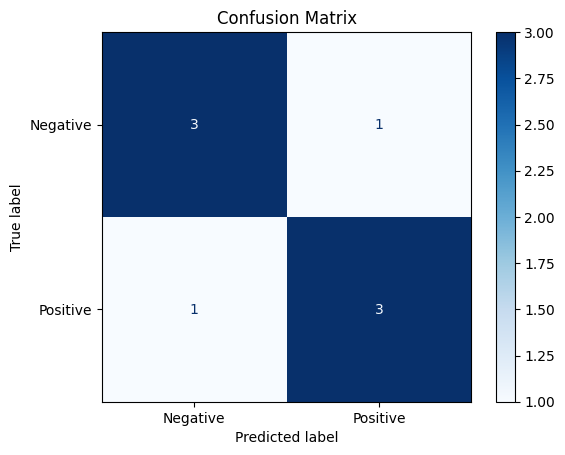

In [1]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = [0, 1, 0, 1, 0, 1, 1, 0]
y_pred = [0, 1, 0, 0, 0, 1, 1, 1]

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

Accuracy : 0.9743589743589743
Precision: 0.9565217391304348
Recall   : 1.0
F1 Score : 0.9777777777777777


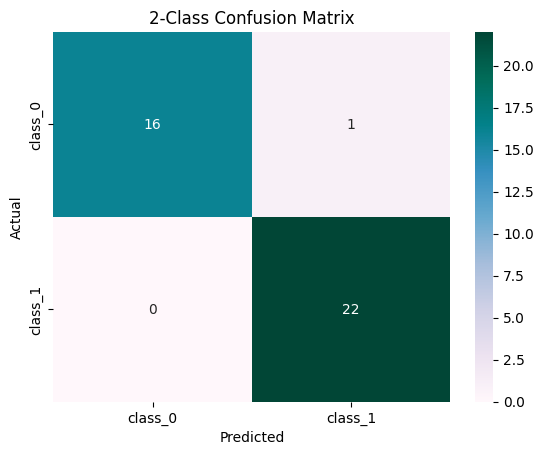

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

wine = load_wine()
x = wine.data[wine.target != 2]
y = wine.target[wine.target != 2]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

model = DecisionTreeClassifier(random_state=1)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="PuBuGn", xticklabels=wine.target_names[:2], yticklabels=wine.target_names[:2])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("2-Class Confusion Matrix")
plt.show()

Accuracy: 0.9555555555555556
Confusion Matrix:
 [[14  0  0]
 [ 0 17  1]
 [ 0  1 12]]


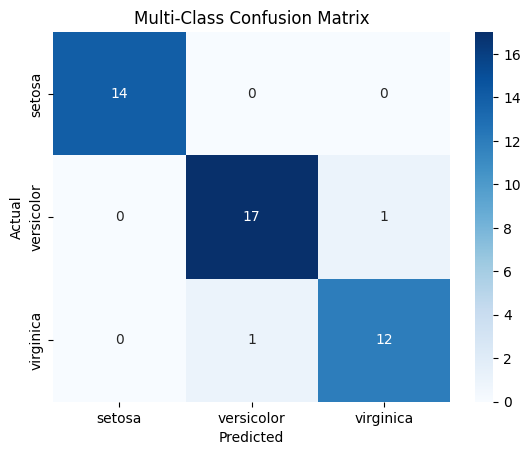

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

model = DecisionTreeClassifier(random_state=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multi-Class Confusion Matrix")
plt.show()

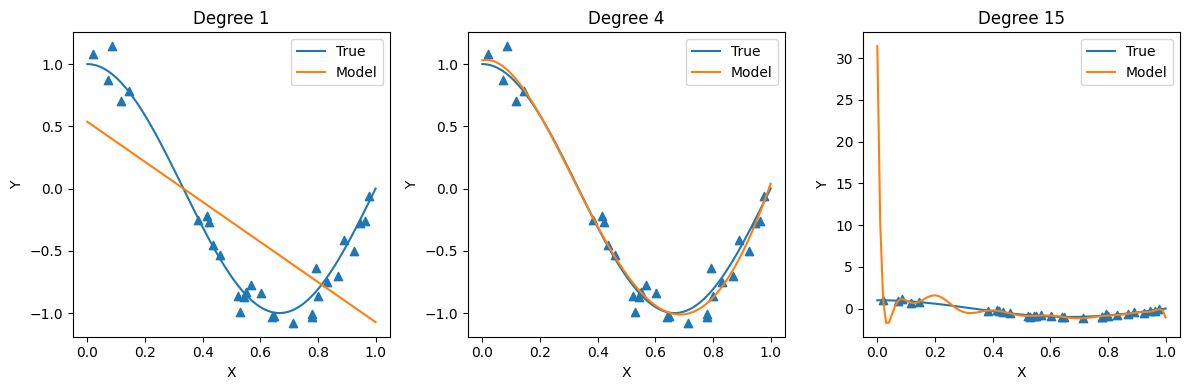

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def f(x):
    return np.cos(1.5 * np.pi * x)

np.random.seed(0)
X = np.sort(np.random.rand(30))
y = f(X) + np.random.randn(30) * 0.1

plt.figure(figsize=(12, 4))

for i, degree in enumerate([1, 4, 15]):
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )
    model.fit(X[:, None], y)

    X_test = np.linspace(0, 1, 100)

    plt.subplot(1, 3, i + 1)
    plt.scatter(X, y, marker="^")
    plt.plot(X_test, f(X_test), label="True")
    plt.plot(X_test, model.predict(X_test[:, None]), label="Model")
    plt.title(f"Degree {degree}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()

plt.tight_layout()
plt.show()

MSE: 0.22751421034522745


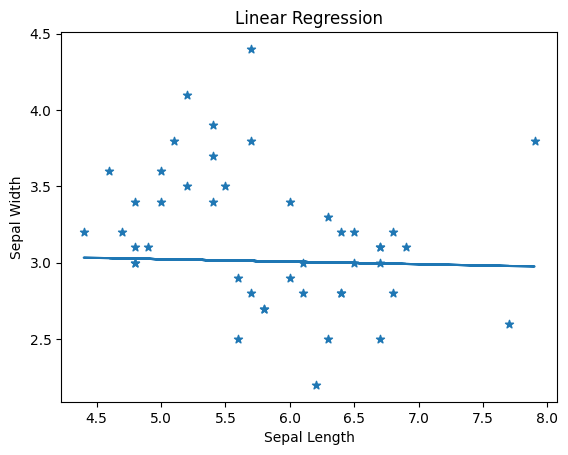

Predicted width: 3.0234458247613016


In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

iris = load_iris()
X = iris.data[:, 0].reshape(-1, 1)
y = iris.data[:, 1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))

plt.scatter(X_test, y_test, marker="*")
plt.plot(X_test, y_pred)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Linear Regression")
plt.show()

print("Predicted width:", model.predict([[5]])[0])

Accuracy: 0.7037037037037037


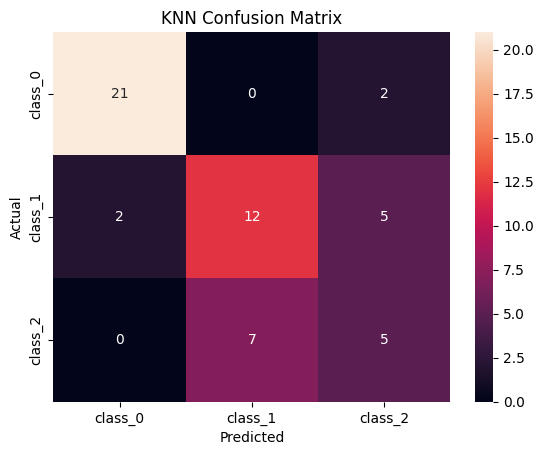

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

wine = load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True, fmt="d",
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

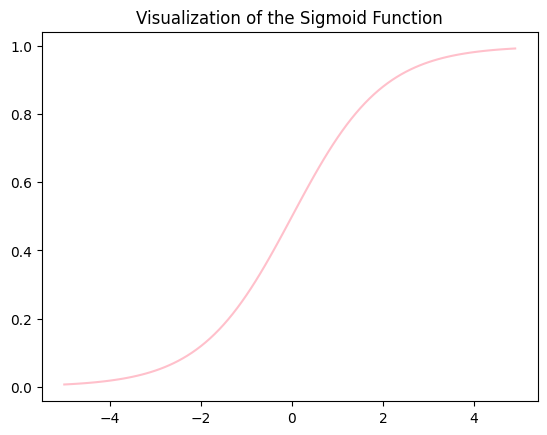

In [12]:
import numpy as np
import matplotlib.pyplot as plt
def sigmoid(z):
  return 1 / (1 + np.exp( - z))
plt.plot(np.arange(-5, 5, 0.1), sigmoid(np.arange(-5, 5, 0.1)),color='pink')
plt.title('Visualization of the Sigmoid Function')
plt.show()

Accuracy: 0.9777777777777777


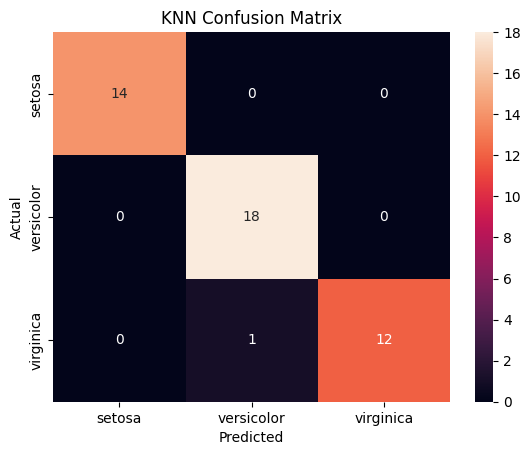

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True, fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

Accuracy: 0.9777777777777777


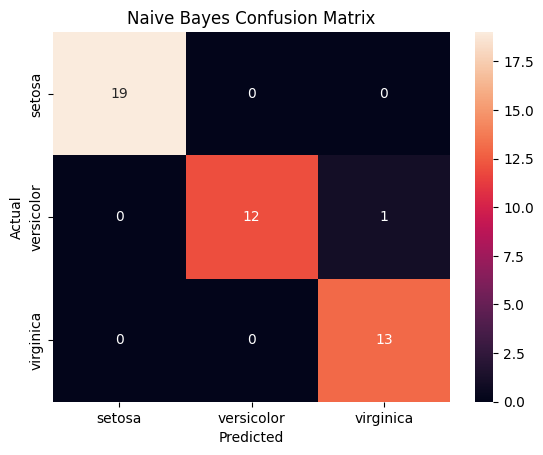

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True, fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

Accuracy: 0.9666666666666667


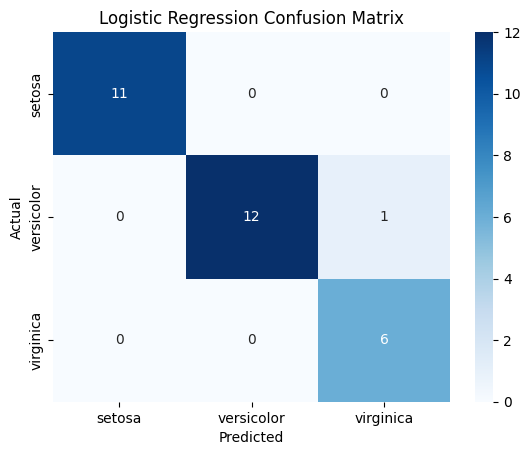

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True, fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()